# Scenario verification: single-scenario robustness and pair composability

This notebook evaluates the robustness of single scenarios over possible parameters of a model, and two different composability policies for pairs of scenarios. The evaluation is capped to pairs for computational, not implementation reasons. 

`RERUN_ANALYSIS = False` (default) reuses cached JSONLs in `results/`. Set to `True` in the setup cell to regenerate

In [31]:
from pathlib import Path
import json
import os
import subprocess
import datetime as _dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid')

In [32]:
RERUN_ANALYSIS = False

# The chosen model will be rerun or retrieved from cache
MODEL_JSON = Path('models/fumagalli2022criminal-investigation/ontology.json')
# MODEL_JSON = Path('models/musso_2021/runningexample.json')

RESULTS_DIR = Path('results')
# All inputs and outputs for a model live under a single folder: results/<model name>/
MODEL_RESULTS_DIR = RESULTS_DIR / MODEL_JSON.parent.name
PROJECT_ROOT = Path('.').resolve().parent.parent

COMBINATION_POLICY = json.loads(Path('target_property_combination_policy.json').read_text())
_cls = COMBINATION_POLICY['classifications']
_scenarios = json.loads(Path('../../src/main/resources/simulation_scenarios.json').read_text())['scenarios']
SCENARIO_IDS = [s['id'] for s in _scenarios]
SCENARIO_CELL = {s['id']: f"{_cls[s['id']]['target']}.{_cls[s['id']]['property']}" for s in _scenarios}

def load_pair_stats(jsonl_path, add_cell=False):
    """One row per unordered scenario pair: runs, SAT count, SAT%."""
    df = pd.read_json(jsonl_path, lines=True)
    df = df[df['tuple_size'] == 2].copy()
    parts = df['scenario_ids'].str.split('|', expand=True)
    df['pair'] = [tuple(sorted([a, b])) for a, b in zip(parts[0], parts[1])]
    df['is_sat'] = df['status'].eq('SAT')
    agg = df.groupby('pair').agg(runs=('is_sat', 'size'), sat=('is_sat', 'sum')).reset_index()
    agg['sat_%'] = (agg['sat'] / agg['runs'] * 100).round(1)
    agg['scenario_a'] = agg['pair'].str[0]
    agg['scenario_b'] = agg['pair'].str[1]
    if add_cell:
        agg['cell'] = agg['scenario_a'].map(SCENARIO_CELL)
    return agg


def _flag(args, name, default=None):
    return args[args.index(name) + 1] if name in args else default

def _output_filename(mode, model, args):
    ts = _dt.datetime.now(_dt.UTC).strftime('%Y%m%d_%H%M%SZ')
    tag = model.parent.name
    if mode == 'single':
        prefix = 'scenario_batch'
        suffix = f"_n{_flag(args, '--samples-per-scenario', '500')}_seed{_flag(args, '--seed', '42')}"
    else:
        prefix = 'scenario_batch_combined' if mode == 'combined' else 'scenario_batch_combined_disallowed'
        suffix = (
            f"_seed{_flag(args, '--seed', '42')}"
            f"_k{_flag(args, '--combine-size', '2')}_{_flag(args, '--class-sharing', 'shared')}"
        )
        if _flag(args, '--sat-cases-from') is not None:
            suffix += f"_satcases{_flag(args, '--cases-per-scenario', '1')}"
        if _flag(args, '--combination-policy') is not None:
            suffix += '_cell_mutex'
    if '--allow-abstract-leaf-instances' in args:
        suffix += '_abstract'
    return f'{prefix}_{ts}_{tag}{suffix}.jsonl'


def run_kotlin(label, mode, extra_args, expected_pattern, model,
                     pattern_contains=None, pattern_excludes=()):
    if not RERUN_ANALYSIS:
        candidates = sorted(
            p for p in MODEL_RESULTS_DIR.rglob(expected_pattern)
            if not p.is_dir()
            and (pattern_contains is None or pattern_contains in p.name)
            and not any(ex in p.name for ex in pattern_excludes)
        )
        path = candidates[-1] 
        print(f'[{label}] {path.name}')
        return path

    def _proj(p):
        return str(Path(p).resolve().relative_to(PROJECT_ROOT))

    model_path = Path(model)
    out_name = _output_filename(mode, model_path, extra_args)
    # Always write under results/<model name>/, whether the input is the model JSON
    # (single-scenario runs) or the transformed .als (combination runs).
    model_dir = MODEL_RESULTS_DIR
    model_dir.mkdir(parents=True, exist_ok=True)
    out_path = model_dir / out_name

    _path_flags = {'--sat-cases-from', '--combination-policy'}
    resolved_extra, skip = [], False
    for a in extra_args:
        if skip:
            resolved_extra.append(_proj(a)); skip = False; continue
        resolved_extra.append(a)
        if a in _path_flags: skip = True

    if model_path.suffix == '.json' and '--transform-out' not in resolved_extra:
        transform_out = model_dir / (out_name.replace('.jsonl', '_transform'))
        transform_out.mkdir(parents=True, exist_ok=True)
        resolved_extra += ['--transform-out', _proj(transform_out)]
    if mode == 'combined_disallowed' and '--policy' not in resolved_extra:
        resolved_extra += ['--policy', 'disallowed']

    runner = ('com.example.batch.SingleScenarioRunner' if mode == 'single'
              else 'com.example.batch.PairwiseScenarioRunner')
    exec_args = ' '.join(['--model', _proj(model_path), '--out', _proj(out_path), *resolved_extra])
    subprocess.run(['mvn', '-q', 'compile'], cwd=PROJECT_ROOT, check=True)
    subprocess.run(['mvn', '-q', 'exec:java', f'-Dexec.mainClass={runner}', f'-Dexec.args={exec_args}'],
                   cwd=PROJECT_ROOT, check=True)
    print(f'[{label}] wrote: {out_path.name}')
    return out_path

print(f'Scenarios: {len(SCENARIO_IDS)}')

Scenarios: 23


## Single-scenario robustness run

Up to n=500 sampled argument combinations per scenario on the chosen model. Produces the SAT%, timeout%, and coverage numbers, and the SAT cases consumed by the composability runs below.

In [33]:
SINGLE_RUN_JSONL = run_kotlin(
    label='stage 0 / single',
    mode='single',
    model=MODEL_JSON,
    extra_args=['--samples-per-scenario', '500', '--seed', '42', '--timeout-seconds', '30'],
    expected_pattern=f'scenario_batch_*_{MODEL_JSON.parent.name}_n500_seed42.jsonl',
)
SAT_CASES_JSONL = str(SINGLE_RUN_JSONL)
TRANSFORMED_MODEL_ALS = str(SINGLE_RUN_JSONL.parent / (SINGLE_RUN_JSONL.stem + '_transform') / 'main.als')
print(f'SAT_CASES_JSONL = {SAT_CASES_JSONL}')
print(f'TRANSFORMED_MODEL_ALS = {TRANSFORMED_MODEL_ALS}')


[stage 0 / single] scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42.jsonl
SAT_CASES_JSONL = results/fumagalli2022criminal-investigation/scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42.jsonl
TRANSFORMED_MODEL_ALS = results/fumagalli2022criminal-investigation/scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42_transform/main.als


### Status counts

In [34]:
print(SINGLE_RUN_JSONL)

df_single = pd.read_json(SINGLE_RUN_JSONL, lines=True)
counts = df_single['status'].value_counts(dropna=False)
summary = pd.DataFrame({
    'count': counts,
    'pct': (counts / counts.sum() * 100).round(1),
})
print(f'Total rows: {len(df_single)}')
print(f'Avg duration (ms): {df_single["duration_ms"].mean():.0f}')
summary

results/fumagalli2022criminal-investigation/scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42.jsonl
Total rows: 4442
Avg duration (ms): 4971


,count,pct
status,,
SAT,3747,84.4
UNSAT,586,13.2
TIMEOUT,109,2.5


## Stage 1 - test original combination policy: target x property

Block any two scenarios with the same target and property. The runner gets the policy via `--combination-policy` and encodes the old policy via explicit mapping in `target_property_combination_policy.json` to use the new confligct-group logic

In [35]:
_cls_df = pd.DataFrame.from_dict(COMBINATION_POLICY['classifications'], orient='index')
cell_grid = (
    _cls_df.groupby(['target', 'property'], observed=False).size()
    .unstack('property', fill_value=0)    
)
cell_grid

property,cardinality,coverage,dynamics,overlap,rigidity,structure
target,,,,,,
association,1,1,1,0,0,1
class,2,1,1,0,2,0
class_comparison,1,0,0,4,0,0
individuals,1,1,2,0,0,0
worlds,1,0,0,0,0,3


In [36]:
STAGE1_JSONL = run_kotlin(
    label='stage 1 / cell-mutex',
    mode='combined_disallowed',
    extra_args=[
        '--combination-policy', 'target_property_combination_policy.json',
        '--sat-cases-from', SAT_CASES_JSONL,
        '--cases-per-scenario', '10',
        '--class-sharing', 'shared',
        '--timeout-seconds', '30',
    ],
    model=TRANSFORMED_MODEL_ALS,
    expected_pattern='scenario_batch_combined_disallowed_*_cell_mutex.jsonl',
)


[stage 1 / cell-mutex] scenario_batch_combined_disallowed_20260521_214446Z_scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42_transform_seed42_k2_shared_satcases10_cell_mutex.jsonl


In [37]:
stage1_pairs = load_pair_stats(STAGE1_JSONL, add_cell=True)
stage1 = stage1_pairs[['scenario_a', 'scenario_b', 'runs', 'sat_%']]
display(stage1)


,scenario_a,scenario_b,runs,sat_%
0,alternative_futures,counterfactual_worlds,1,0.0
1,alternative_futures,linear_branch,1,0.0
2,counterfactual_worlds,linear_branch,1,0.0
3,exclusive_instantiation,extension_comparison,100,96.0
4,exclusive_instantiation,multiple_instantiation,100,94.0
5,exclusive_instantiation,temporal_multiple_instantiation,100,99.0
6,extension_comparison,multiple_instantiation,100,97.0
7,extension_comparison,temporal_multiple_instantiation,100,100.0
8,extension_size,temporal_extension_size,100,83.0
9,mandatory_antirigidity,pseudo_rigid,70,81.4


## Stage 2 — confirmatory runs: world-shape-only policy

Stage 1 shows that only the `world_shape` group conflicts unconditionally; all other pairs are satisfiable under some binding. This motivates restricting the disallowed set to `world_shape` alone, and raises the question of how well the remaining pairs compose.

This stage 1) checks that the now disallowed cases are always UNSAT 2) investigates whether satisfiability is parameter coupled by running 3 different class-sharing runs: a) all pairs of combined scenarios share at least one bound class b) no pair share arguments c) no restriction on paramter (random sampling from the SAT cases)

In [38]:
WORLD_SHAPE_DISALLOWED = run_kotlin(
    label='stage 2 / disallowed',
    mode='combined_disallowed',
    extra_args=['--sat-cases-from', SAT_CASES_JSONL, '--cases-per-scenario', '5',
                '--class-sharing', 'shared', '--timeout-seconds', '30'],
    model=TRANSFORMED_MODEL_ALS,
    expected_pattern='scenario_batch_combined_disallowed_*.jsonl',
    pattern_excludes=('cell_mutex',),
)


[stage 2 / disallowed] scenario_batch_combined_disallowed_20260522_091804Z_scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42_transform_seed42_k2_shared_satcases5.jsonl


In [39]:
WORLD_SHAPE_ALLOWED_SHARED = run_kotlin(
    label='stage 2 / allowed / shared',
    mode='combined',
    extra_args=['--policy', 'allowed', '--sat-cases-from', SAT_CASES_JSONL,
                '--cases-per-scenario', '5', '--class-sharing', 'shared', '--timeout-seconds', '30'],
    model=TRANSFORMED_MODEL_ALS,
    expected_pattern='scenario_batch_combined_*.jsonl',
    pattern_contains='_shared',
    pattern_excludes=('disallowed', 'cell_mutex'),
)


[stage 2 / allowed / shared] scenario_batch_combined_20260522_154937Z_scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42_transform_seed42_k2_shared_satcases5.jsonl


In [40]:
WORLD_SHAPE_ALLOWED_DISJOINT = run_kotlin(
    label='stage 2 / allowed / disjoint',
    mode='combined',
    extra_args=['--policy', 'allowed', '--sat-cases-from', SAT_CASES_JSONL,
                '--cases-per-scenario', '5', '--class-sharing', 'disjoint', '--timeout-seconds', '30'],
    model=TRANSFORMED_MODEL_ALS,
    expected_pattern='scenario_batch_combined_*.jsonl',
    pattern_contains='_disjoint',
    pattern_excludes=('disallowed', 'cell_mutex'),
)


[stage 2 / allowed / disjoint] scenario_batch_combined_20260523_171735Z_scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42_transform_seed42_k2_disjoint_satcases5.jsonl


In [41]:
WORLD_SHAPE_ALLOWED_OVERLAP = run_kotlin(
    label='stage 2 / allowed / overlap',
    mode='combined',
    extra_args=['--sat-cases-from', SAT_CASES_JSONL, '--cases-per-scenario', '5',
                '--class-sharing', 'overlap', '--timeout-seconds', '30'],
    model=TRANSFORMED_MODEL_ALS,
    expected_pattern='scenario_batch_combined_*.jsonl',
    pattern_contains='_overlap',
    pattern_excludes=('disallowed', 'cell_mutex'),
)


[stage 2 / allowed / overlap] scenario_batch_combined_20260524_064142Z_scenario_batch_20260521_153621Z_fumagalli2022criminal-investigation_n500_seed42_transform_seed42_k2_overlap_satcases5.jsonl


### Stage 2 - analysis

Verifies that (a) the three `world_shape` pairs are UNSAT in every run, and (b) no allowed pair is UNSAT under both `overlap` and `disjoint`

In [42]:
disallowed_pairs = load_pair_stats(WORLD_SHAPE_DISALLOWED)
display(disallowed_pairs)

assert len(disallowed_pairs) == 3, f'expected 3 world_shape pairs, got {len(disallowed_pairs)}'
assert (disallowed_pairs['sat_%'] == 0).all(), 'some disallowed pairs were SAT'


,pair,runs,sat,sat_%,scenario_a,scenario_b
0,"(alternative_futures, counterfactual_worlds)",1,0,0.0,alternative_futures,counterfactual_worlds
1,"(alternative_futures, linear_branch)",1,0,0.0,alternative_futures,linear_branch
2,"(counterfactual_worlds, linear_branch)",1,0,0.0,counterfactual_worlds,linear_branch


In [43]:
allowed_shared   = load_pair_stats(WORLD_SHAPE_ALLOWED_SHARED).rename(columns={'sat_%': 'sat_%_shared',   'runs': 'runs_shared',   'sat': 'sat_shared'})
allowed_disjoint = load_pair_stats(WORLD_SHAPE_ALLOWED_DISJOINT).rename(columns={'sat_%': 'sat_%_disjoint', 'runs': 'runs_disjoint', 'sat': 'sat_disjoint'})
allowed_overlap  = load_pair_stats(WORLD_SHAPE_ALLOWED_OVERLAP).rename(columns={'sat_%': 'sat_%_overlap',  'runs': 'runs_overlap',  'sat': 'sat_overlap'})

key = ['scenario_a', 'scenario_b']
comparison = (
    allowed_shared
    .merge(allowed_overlap,  on=key, how='outer')
    .merge(allowed_disjoint, on=key, how='outer')
)

unsampled = comparison[comparison['sat_%_overlap'].isna() & comparison['sat_%_disjoint'].isna()]
assert unsampled.empty, f'{len(unsampled)} pair(s) unsampled under both overlap and disjoint'
print(f'Allowed pairs compared: {len(comparison)} — all sampled in at least one mode.')

Allowed pairs compared: 273 — all sampled in at least one mode.


### Parameter-coupling diagnostics

Δ distribution, fully-coupled pair count, and per-pair Fisher's exact test with Bonferroni correction for repeated tests. 

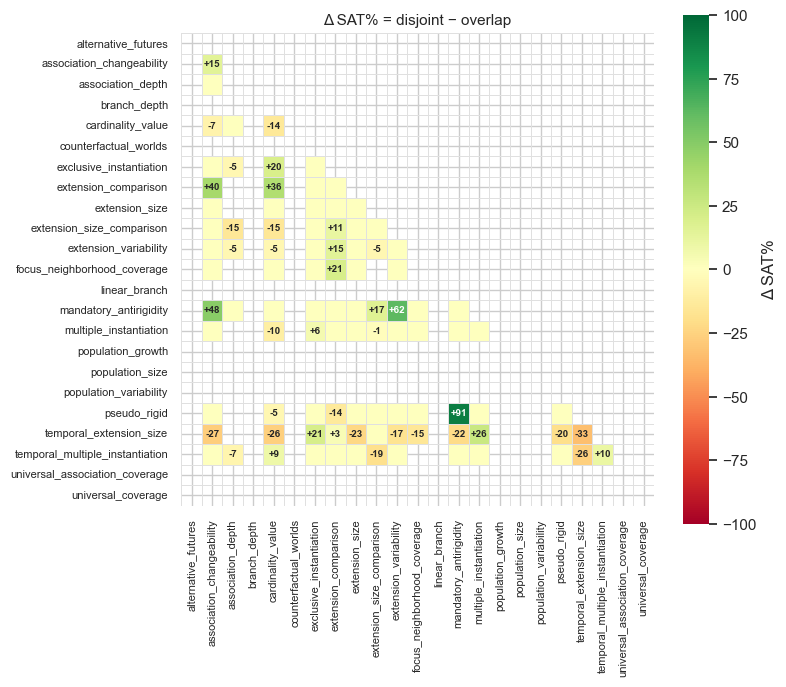

In [44]:
scenarios_in_play = sorted(set(comparison['scenario_a']).union(comparison['scenario_b']))
n = len(scenarios_in_play)
idx = {s: i for i, s in enumerate(scenarios_in_play)}

def _build_mat(value_col):
    m = np.full((n, n), np.nan)
    for _, r in comparison.iterrows():
        v = r.get(value_col)
        if pd.isna(v):
            continue
        i, j = idx[r['scenario_a']], idx[r['scenario_b']]
        m[i, j] = m[j, i] = v
    return m

mat_overlap  = _build_mat('sat_%_overlap')
mat_disjoint = _build_mat('sat_%_disjoint')
_upper_mask  = np.triu(np.ones((n, n), dtype=bool), k=1)

mat_delta_do = mat_disjoint - mat_overlap

annot = np.full((n, n), '', dtype=object)
for i in range(n):
    for j in range(n):
        v = mat_delta_do[i, j]
        if not np.isnan(v) and abs(v) > 0.05:
            annot[i, j] = f'{v:+.0f}'

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    mat_delta_do, ax=ax, vmin=-100, vmax=100, center=0,
    cmap=plt.cm.RdYlGn,
    mask=_upper_mask,
    xticklabels=scenarios_in_play, yticklabels=scenarios_in_play,
    cbar_kws={'label': 'Δ SAT%'},
    square=True, annot=annot, fmt='', annot_kws={'fontsize': 7, 'fontweight': 'bold'},
    linewidths=0.4, linecolor='#e0e0e0',
)
ax.set_title('Δ SAT% = disjoint − overlap', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


In [45]:
covered = set(comparison['scenario_a']) | set(comparison['scenario_b'])
missing = sorted(set(SCENARIO_IDS) - covered)
print('scenarios missing from allowed-pair runs: {missing}')

scenarios missing from allowed-pair runs: {missing}


In [46]:
from scipy.stats import fisher_exact

obs = comparison.dropna(subset=['sat_%_overlap', 'sat_%_disjoint']).copy()
obs['delta_do'] = obs['sat_%_disjoint'] - obs['sat_%_overlap']
n_obs = len(obs)

print(f'Observable pairs (runs in both modes): {n_obs} / {len(comparison)}')
print()

print('1. Distribution of Δ = sat%_disjoint - sat%_overlap')
q = obs['delta_do'].describe(percentiles=[0.25, 0.5, 0.75])
print(f"   min {q['min']:.1f}, 25% {q['25%']:.1f}, median {q['50%']:.1f}, 75% {q['75%']:.1f}, max {q['max']:.1f}")
print(f"   Δ >  0 : {(obs['delta_do'] >  0).sum()}")
print(f"   Δ == 0 : {(obs['delta_do'] == 0).sum()}")
print(f"   Δ <  0 : {(obs['delta_do'] <  0).sum()}")
print()

print('2. Class-sharing-determined pairs (SAT in one mode, never in the other)')
induced  = obs[(obs['sat_%_overlap'] == 0) & (obs['sat_%_disjoint'] > 0)]
required = obs[(obs['sat_%_disjoint'] == 0) & (obs['sat_%_overlap'] > 0)]
print(f"   sharing-induced UNSAT (overlap=0, disjoint>0):  {len(induced)} / {n_obs} pairs")
print(f"   sharing-required SAT  (disjoint=0, overlap>0):  {len(required)} / {n_obs} pairs")
_cat_cols = ['scenario_a', 'scenario_b', 'runs_overlap', 'runs_disjoint', 'sat_%_overlap', 'sat_%_disjoint']
display(induced[_cat_cols])
display(required[_cat_cols])
print()

# 3. Per-pair Fisher's exact on the 2x2 table
def _fisher_p(row):
    a = (row['sat_overlap'])
    runs_o = (row['runs_overlap'])
    c = (row['sat_disjoint'])
    runs_d = (row['runs_disjoint'])
    b = runs_o - a
    d = runs_d - c
    _, p = fisher_exact([[a, b], [c, d]], alternative='two-sided')
    return p

obs['fisher_p'] = obs.apply(_fisher_p, axis=1)

alpha_raw  = 0.05
alpha_bonf = alpha_raw / n_obs

n_sig_raw  = int((obs['fisher_p'] < alpha_raw).sum())
n_sig_bonf = int((obs['fisher_p'] < alpha_bonf).sum())

print("3. Per-pair Fisher's exact test for class-sharing dependence")
print(f"   raw  p < {alpha_raw} : {n_sig_raw:3d} / {n_obs}")
print(f"   Bonferroni p < {alpha_bonf:.4g} : {n_sig_bonf:3d} / {n_obs}")
print()

cols = ['scenario_a', 'scenario_b',
        'sat_overlap', 'runs_overlap', 'sat_disjoint', 'runs_disjoint',
        'sat_%_overlap', 'sat_%_disjoint', 'delta_do', 'fisher_p']
print(f'Pairs significant at raw alpha={alpha_raw} (sorted by p):')
sig = obs[obs['fisher_p'] < alpha_raw].sort_values('fisher_p')
display(sig[cols])


Observable pairs (runs in both modes): 95 / 273

1. Distribution of Δ = sat%_disjoint - sat%_overlap
   min -33.3, 25% 0.0, median 0.0, 75% 0.0, max 91.3
   Δ >  0 : 17
   Δ == 0 : 55
   Δ <  0 : 23

2. Class-sharing-determined pairs (SAT in one mode, never in the other)
   sharing-induced UNSAT (overlap=0, disjoint>0):  1 / 95 pairs
   sharing-required SAT  (disjoint=0, overlap>0):  0 / 95 pairs


,scenario_a,scenario_b,runs_overlap,runs_disjoint,sat_%_overlap,sat_%_disjoint
223,mandatory_antirigidity,pseudo_rigid,2.0,23.0,0.0,91.3


,scenario_a,scenario_b,runs_overlap,runs_disjoint,sat_%_overlap,sat_%_disjoint



3. Per-pair Fisher's exact test for class-sharing dependence
   raw  p < 0.05 :   2 / 95
   Bonferroni p < 0.0005263 :   0 / 95

Pairs significant at raw alpha=0.05 (sorted by p):


,scenario_a,scenario_b,sat_overlap,runs_overlap,sat_disjoint,runs_disjoint,sat_%_overlap,sat_%_disjoint,delta_do,fisher_p
223,mandatory_antirigidity,pseudo_rigid,0.0,2.0,21.0,23.0,0.0,91.3,91.3,0.02000
185,extension_variability,mandatory_antirigidity,1.0,3.0,21.0,22.0,33.3,95.5,62.2,0.02913


In [47]:
# Always-UNSAT across observed modes:
# pairs whose SAT% is 0 in every mode where they were actually run
# (i.e., for each mode in {shared, overlap, disjoint}, either runs_<mode> > 0 and sat_%_<mode> == 0, or runs_<mode> == 0).
# Complements the overlap-vs-disjoint sharing-induced UNSAT check above by also covering
# pairs that don't appear in both of those modes (e.g., parameter-free scenarios skipped from overlap).

modes = ['shared', 'overlap', 'disjoint']
def _max_sat_observed(row):
    pcts = [row[f'sat_%_{m}'] for m in modes
            if (row.get(f'runs_{m}') or 0) > 0 and not pd.isna(row[f'sat_%_{m}'])]
    return max(pcts) if pcts else None

comparison['_max_sat_observed'] = comparison.apply(_max_sat_observed, axis=1)
always_unsat = comparison[comparison['_max_sat_observed'] == 0.0]

print(f'Always-UNSAT across all observed modes: {len(always_unsat)} / {len(comparison)} pairs')
_cols = ['scenario_a', 'scenario_b',
         'runs_shared', 'sat_%_shared',
         'runs_overlap', 'sat_%_overlap',
         'runs_disjoint', 'sat_%_disjoint']
display(always_unsat[_cols])

comparison.drop(columns=['_max_sat_observed'], inplace=True)


Always-UNSAT across all observed modes: 1 / 273 pairs


,scenario_a,scenario_b,runs_shared,sat_%_shared,runs_overlap,sat_%_overlap,runs_disjoint,sat_%_disjoint
1,alternative_futures,association_changeability,5,0.0,NaN,NaN,5.0,0.0
